In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime
import seaborn as sns
import plotly.express as px
import inspect
import time
import warnings
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.ar_model import AutoReg
%matplotlib inline

In [68]:
df = pd.read_csv('E:\Document\PROJECT_1\data\hanoi-aqi-weather-data.csv')
df_2 = pd.read_csv('E:\Document\PROJECT_1\data\hanoi-aqi-weather-data-TEST.csv')
df['Local Time'] = pd.to_datetime(df['Local Time'])
df.set_index('Local Time', inplace=True)
df_2['Local Time'] = pd.to_datetime(df_2['Local Time'])
df_2.set_index('Local Time', inplace=True)
df.head()

,UTC Time,City,Country Code,Timezone,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,UV Index,Wind Speed
Local Time,,,,,,,,,,,,,,,,,,
2023-01-01 00:00:00,2022-12-31T17:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,155,224.5,9.0,55.7,73.8,59.0,62.3,87,0.0,1024,73,14.8,0.0,0.66
2023-01-01 01:00:00,2022-12-31T18:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,171,206.0,6.0,56.0,88.8,71.0,59.0,87,0.0,1023,75,14.6,0.0,1.00
2023-01-01 02:00:00,2022-12-31T19:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,179,203.7,6.0,54.0,96.3,77.0,58.0,83,0.0,1023,79,14.3,0.0,1.00
2023-01-01 03:00:00,2022-12-31T20:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,199,201.3,6.0,52.0,115.0,92.0,57.0,79,0.0,1023,82,14.1,0.0,1.00
2023-01-01 04:00:00,2022-12-31T21:00:00,Hoàn Kiếm,VN,Asia/Ho_Chi_Minh,161,199.0,6.0,50.0,80.0,64.0,56.0,75,0.0,1022,86,13.8,0.0,1.00


In [69]:
df_pm25_hourly = df[['PM25']].copy()
df_pm25_daily = df_pm25_hourly.resample('D')['PM25'].agg('mean')
df_pm25 = df_pm25_daily
df_pm25

Local Time
2023-01-01     71.541667
2023-01-02     90.375000
2023-01-03     65.916667
2023-01-04     97.166667
2023-01-05     72.500000
                 ...    
2024-12-27     49.958333
2024-12-28     44.167083
2024-12-29     78.597083
2024-12-30    100.277917
2024-12-31     86.299500
Freq: D, Name: PM25, Length: 731, dtype: float64

In [70]:
# Chuyển Series -> DataFrame
df_pm25_df = df_pm25.to_frame().reset_index()

# Xuất ra file Excel
df_pm25_df.to_excel(r'E:\Document\PROJECT_1\data\pm25_daily.xlsx', 
                    index=False,  # không xuất cột index mặc định
                    sheet_name='PM25_Daily')

print("✅ Xuất thành công: pm25_daily.xlsx")

✅ Xuất thành công: pm25_daily.xlsx


In [71]:
df_pm25_hourly_new = df_2[['PM25']].copy()
df_pm25_daily_new = df_pm25_hourly_new.resample('D')['PM25'].agg('mean')
df_pm25_new = df_pm25_daily_new
df_pm25_new

Local Time
2025-02-01    33.465000
2025-02-02    31.416250
2025-02-03    22.632083
2025-02-04    31.446667
2025-02-05    58.430417
                ...    
2025-10-27    34.200833
2025-10-28    47.288333
2025-10-29    57.395417
2025-10-30    45.002917
2025-10-31    23.131818
Freq: D, Name: PM25, Length: 273, dtype: float64

In [72]:
df_pm25.info()

<class 'pandas.core.series.Series'>
DatetimeIndex: 731 entries, 2023-01-01 to 2024-12-31
Freq: D
Series name: PM25
Non-Null Count  Dtype  
--------------  -----  
731 non-null    float64
dtypes: float64(1)
memory usage: 11.4 KB


In [73]:
adf_result = adfuller(df_pm25)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:', adf_result[4])

ADF Statistic: -6.5148641359401935
p-value: 1.0776256378814557e-08
Critical Values: {'1%': -3.4393644334758475, '5%': -2.8655182850048306, '10%': -2.568888486973192}


<Axes: title={'center': 'Hanoi PM2.5 Levels, Daily Data'}, xlabel='Date', ylabel='PM2.5 Level'>

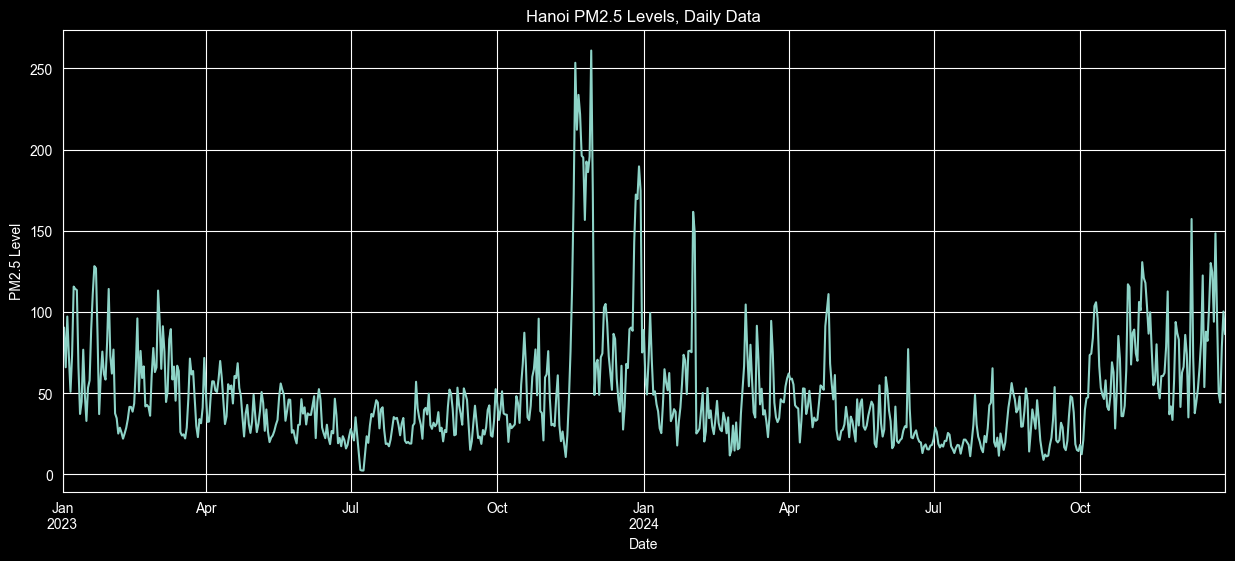

In [74]:

fig, ax = plt.subplots(figsize=(15, 6))
df_pm25.plot(xlabel = "Date",ylabel= "PM2.5 Level",
                           title= "Hanoi PM2.5 Levels, Daily Data", ax=ax)

Text(0.5, 1.0, 'Hanoi PM2.5 Readings, ACF')

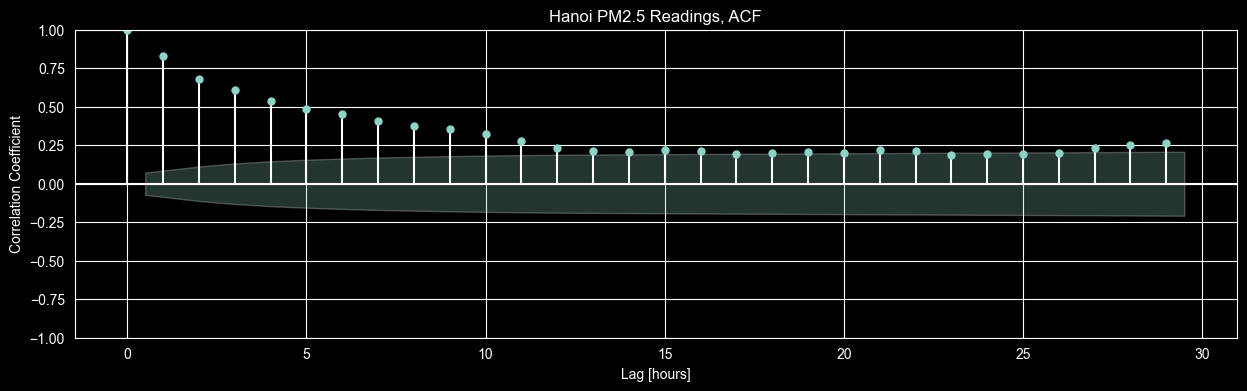

In [75]:

fig, ax = plt.subplots(figsize=(15, 4))
plot_acf(df_pm25, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Hanoi PM2.5 Readings, ACF")

Text(0.5, 1.0, 'Hanoi PM2.5 Readings, PACF')

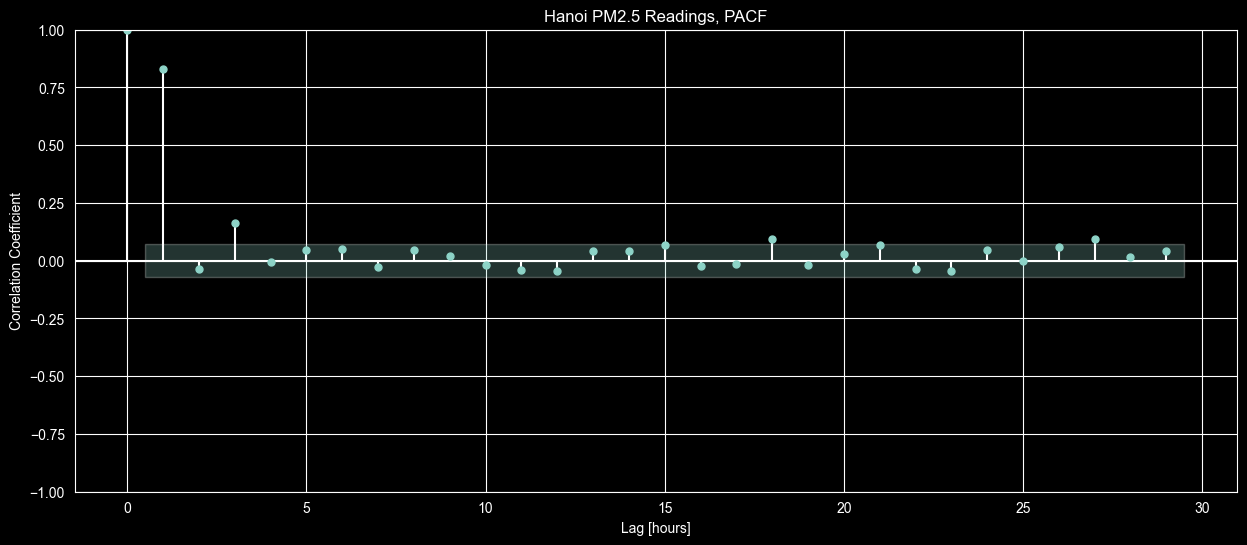

In [76]:
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(df_pm25, ax=ax)
plt.xlabel("Lag [hours]")
plt.ylabel("Correlation Coefficient")
plt.title("Hanoi PM2.5 Readings, PACF")

In [77]:
from statsmodels.tsa.stattools import acf, pacf

# Tính toán giá trị ACF
acf_values = acf(df_pm25, nlags=30)
print("ACF Values:")
print(acf_values)
print()

# Tính toán giá trị PACF
pacf_values = pacf(df_pm25, nlags=30)
print("PACF Values:")
print(pacf_values)

ACF Values:
[1.         0.8318345  0.68120999 0.6071318  0.54026892 0.48526443
 0.4505717  0.40567924 0.37353712 0.35317632 0.32204188 0.27875251
 0.23205856 0.2097161  0.20668477 0.21699742 0.20990811 0.19037557
 0.20192397 0.2048931  0.200617   0.21692296 0.21362843 0.18756037
 0.1902888  0.19382632 0.20020349 0.23104868 0.25152455 0.26508183
 0.29204193]

PACF Values:
[ 1.00000000e+00  8.32973997e-01 -3.51678932e-02  1.63291732e-01
 -5.85967474e-03  4.81100217e-02  4.97739613e-02 -2.55543469e-02
  4.72872127e-02  2.24349446e-02 -1.76001063e-02 -4.02010456e-02
 -4.57013655e-02  4.52583172e-02  4.27404266e-02  6.95492475e-02
 -2.20388165e-02 -1.49361272e-02  9.62861783e-02 -1.84846989e-02
  2.92705834e-02  7.25379651e-02 -3.54955336e-02 -4.40180356e-02
  4.89532070e-02  1.75789400e-04  6.04765775e-02  1.00863504e-01
  1.83581470e-02  4.40824720e-02  7.35591644e-02]


In [78]:
int(len(df_pm25)) *0.8

584.8000000000001

In [79]:
cutoff_test = int(len(df_pm25)* 0.8) 
df_pm25_train = df_pm25.iloc[:cutoff_test]
df_pm25_test = df_pm25.iloc[cutoff_test:]
print("df_pm25_train shape:", df_pm25_train.shape)
print("df_pm25_test shape:", df_pm25_test.shape)

df_pm25_train shape: (584,)
df_pm25_test shape: (147,)


In [80]:
# Perform ADF test
adf_result = adfuller(df_pm25_train)
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:', adf_result[4])

ADF Statistic: -5.830512605524053
p-value: 3.985322860994825e-07
Critical Values: {'1%': -3.4416553818946145, '5%': -2.8665274458710064, '10%': -2.5694261699959413}


In [81]:
df_pm25_train_mean = df_pm25_train.mean()
df_pm25_pred_baseline = [df_pm25_train_mean]*len(df_pm25_train)
mae_baseline = mean_absolute_error(df_pm25_train, df_pm25_pred_baseline)

print("Mean P2 Reading:", round(df_pm25_train_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean P2 Reading: 47.51
Baseline MAE: 22.86


In [82]:
p_params = range(0, 8, 1)
q_params = range(0, 3, 1)
list(p_params)

[0, 1, 2, 3, 4, 5, 6, 7]

In [83]:

# Create dictionary to store MAEs
# mae_grid = dict()
# Outer loop: Iterate through possible values for `p`
# for p in p_params:
    # Create key-value pair in dict. Key is `p`, value is empty list.
    # mae_grid[p] = list()
    # Inner loop: Iterate through possible values for `q`
    # for q in q_params:
        # Combination of hyperparameters for model
        # order = (p, 0, q)
        # Note start time
        # start_time = time.time()
        # Train model
        # model = ARIMA(df_pm25_train, order=order).fit()
        # Calculate model training time
        # elapsed_time = round(time.time() - start_time, 2)
        # print(f"Trained ARIMA {order} in {elapsed_time} seconds.")
        # Generate in-sample (training) predictions
        # df_pm25_pred = model.predict()
        # Calculate training MAE
        # mae = mean_absolute_error(df_pm25_train, df_pm25_pred)
        # Append MAE to list in dictionary
        # mae_grid[p].append(mae)

# print()
# print(mae_grid)
mae_grid = {}          # {p: [MAE(q0), MAE(q1), ...]}
aic_grid = {}          # {p: [AIC(q0), AIC(q1), ...]}
best = {"order": None, "MAE": float("inf"), "AIC": float("inf")}

for p in p_params:
    mae_grid[p] = []
    aic_grid[p] = []
    for q in q_params:
        order = (p, 0, q)   # d = 0 vì ADF cho thấy dừng
        try:
            t0 = time.time()
            model = ARIMA(
                df_pm25_train,
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            ).fit()
            elapsed = round(time.time() - t0, 2)
            print(f"Trained ARIMA{order} in {elapsed}s (AIC={model.aic:.2f}).")

            # In-sample prediction - dùng fittedvalues an toàn hơn
            yhat = model.fittedvalues

            mae = mean_absolute_error(df_pm25_train[len(df_pm25_train) - len(yhat):], yhat)
            mae_grid[p].append(mae)
            aic_grid[p].append(model.aic)

            # Cập nhật best theo AIC (khuyến nghị)
            if model.aic < best["AIC"]:
                best = {"order": order, "MAE": mae, "AIC": model.aic}

        except Exception as e:
            print(f"Skip ARIMA{order}: {e}")
            mae_grid[p].append(None)
            aic_grid[p].append(None)

print("\n" + "="*50)
print("Best model by AIC:", best)
print("="*50)
print("\nMAE grid:", mae_grid)
print("\nAIC grid:", aic_grid)

Trained ARIMA(0, 0, 0) in 0.06s (AIC=5808.19).
Trained ARIMA(0, 0, 1) in 0.06s (AIC=5353.32).
Trained ARIMA(0, 0, 2) in 0.08s (AIC=5203.53).
Trained ARIMA(1, 0, 0) in 0.0s (AIC=5065.06).
Trained ARIMA(1, 0, 1) in 0.05s (AIC=5055.39).
Trained ARIMA(1, 0, 2) in 0.06s (AIC=5036.22).
Trained ARIMA(2, 0, 0) in 0.02s (AIC=5056.38).
Trained ARIMA(2, 0, 1) in 0.17s (AIC=5048.42).
Trained ARIMA(2, 0, 2) in 0.13s (AIC=5037.66).
Trained ARIMA(3, 0, 0) in 0.02s (AIC=5038.84).
Trained ARIMA(3, 0, 1) in 0.09s (AIC=5037.30).
Trained ARIMA(3, 0, 2) in 0.34s (AIC=5031.82).
Trained ARIMA(4, 0, 0) in 0.03s (AIC=5027.83).
Trained ARIMA(4, 0, 1) in 0.11s (AIC=5028.57).
Trained ARIMA(4, 0, 2) in 0.44s (AIC=5025.62).
Trained ARIMA(5, 0, 0) in 0.03s (AIC=5018.94).
Trained ARIMA(5, 0, 1) in 0.26s (AIC=5020.33).
Trained ARIMA(5, 0, 2) in 0.39s (AIC=5019.42).
Trained ARIMA(6, 0, 0) in 0.03s (AIC=5011.45).
Trained ARIMA(6, 0, 1) in 0.19s (AIC=5012.51).
Trained ARIMA(6, 0, 2) in 0.27s (AIC=5014.51).
Trained ARIMA(


MAE Grid:
       0      1      2      3      4      5      6      7
0  22.84  12.49  12.49  12.33  12.36  12.33  12.30  12.29
1  16.30  12.50  12.43  12.35  12.34  12.33  12.24  12.25
2  14.40  12.33  12.35  12.39  12.48  12.37  12.24  12.44

AIC Grid:
         0        1        2        3        4        5        6        7
0  5808.19  5065.06  5056.38  5038.84  5027.83  5018.94  5011.45  5004.41
1  5353.32  5055.39  5048.42  5037.30  5028.57  5020.33  5012.51  5006.42
2  5203.53  5036.22  5037.66  5031.82  5025.62  5019.42  5014.51  4996.70


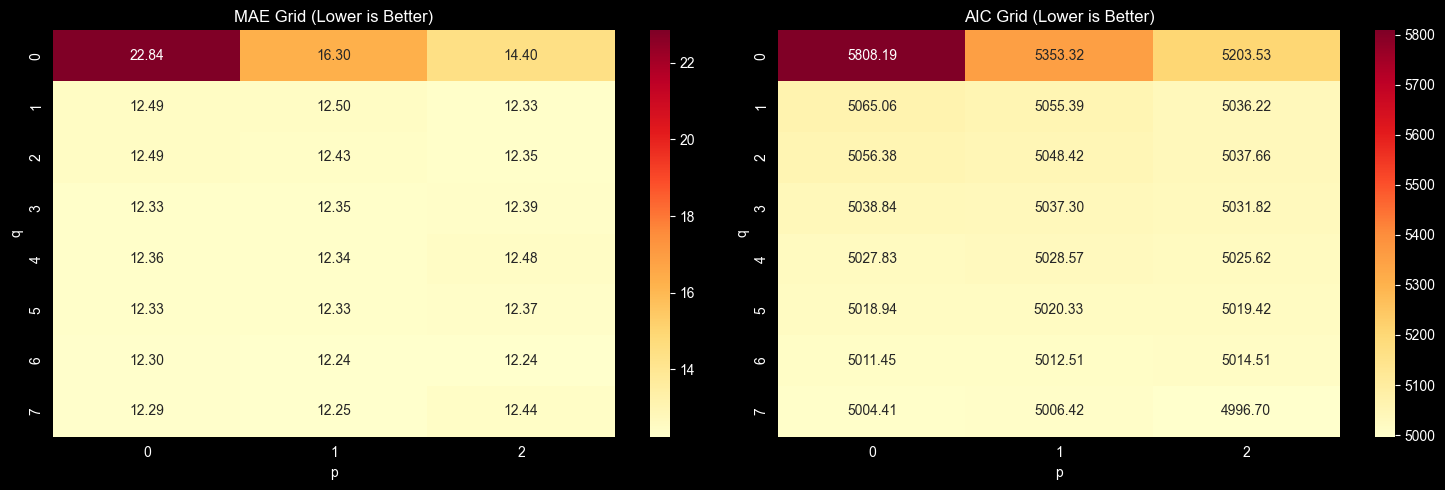

In [84]:
# Sau khi chạy grid search
mae_df = pd.DataFrame(mae_grid)
aic_df = pd.DataFrame(aic_grid)

print("\nMAE Grid:")
print(mae_df.round(2))
print("\nAIC Grid:")
print(aic_df.round(2))

# Vẽ heatmap
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(mae_df.T, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[0])
axes[0].set_title('MAE Grid (Lower is Better)')
axes[0].set_xlabel('p')
axes[0].set_ylabel('q')

sns.heatmap(aic_df.T, annot=True, fmt='.2f', cmap='YlOrRd', ax=axes[1])
axes[1].set_title('AIC Grid (Lower is Better)')
axes[1].set_xlabel('p')
axes[1].set_ylabel('q')
plt.tight_layout()
plt.show()

In [85]:
mae_df = pd.DataFrame(mae_grid)
mae_df.round(4)

,0,1,2,3,4,5,6,7
0,22.8443,12.4928,12.4935,12.3319,12.3628,12.3333,12.3002,12.2891
1,16.2956,12.4998,12.4337,12.3524,12.3429,12.3272,12.2420,12.2517
2,14.4037,12.3281,12.3470,12.3865,12.4781,12.3673,12.2425,12.4412


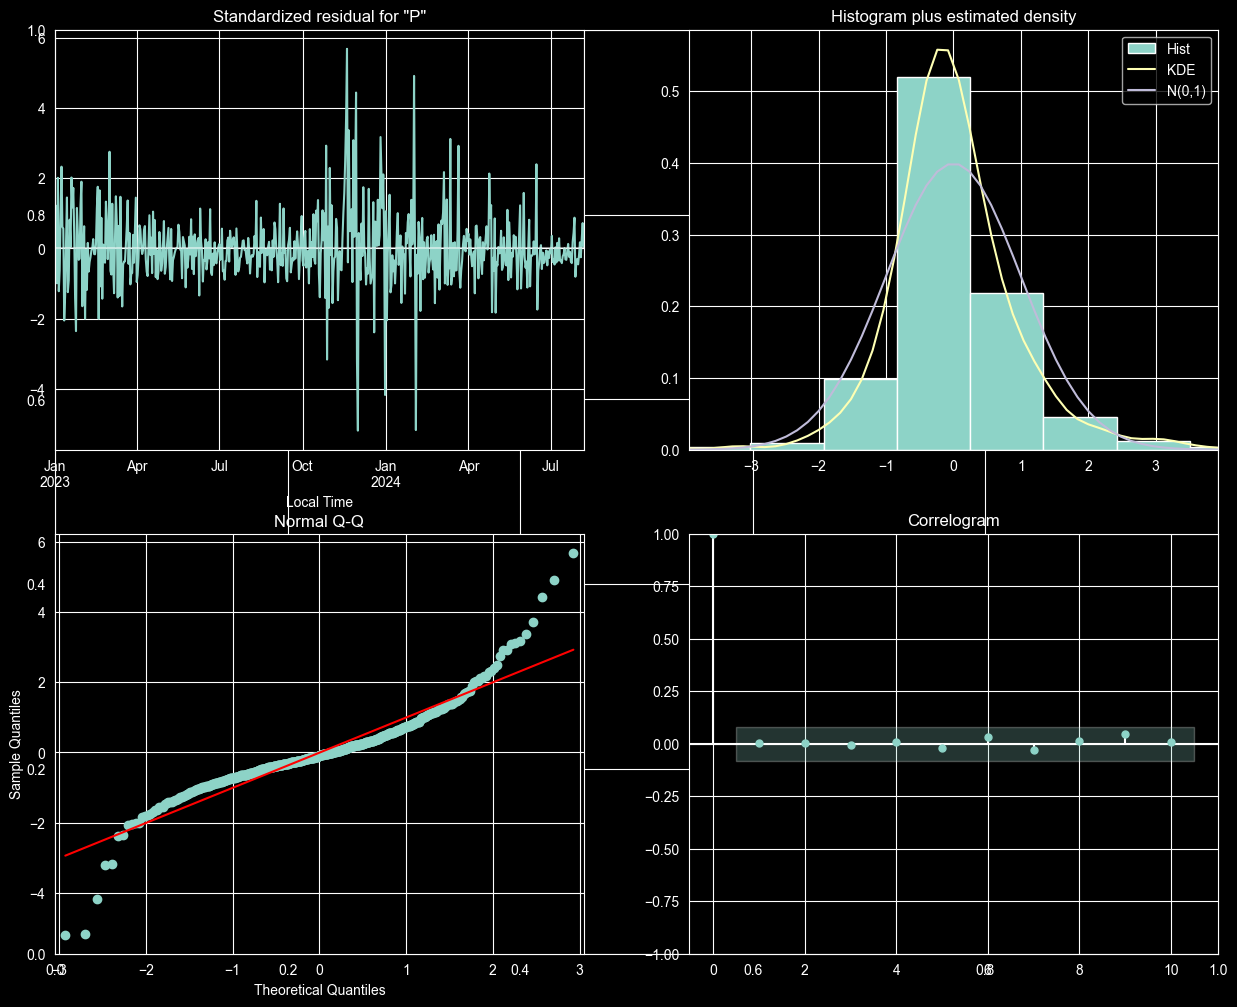

In [86]:
model = ARIMA(df_pm25_train, order=(7,0,2))
results = model.fit()
fig, ax = plt.subplots(figsize=(15, 12))
results.plot_diagnostics(fig=fig)
# Save the plot as an image file (e.g., PNG)
plt.savefig('example_plot.png')

In [87]:
df_pm25_pred_wfv = pd.Series()
history = df_pm25_train.copy()
for i in range(len(df_pm25_test)):
    model = ARIMA(history, order = (7, 0, 2)).fit()
    next_pred = model.forecast()
    df_pm25_pred_wfv = pd.concat([df_pm25_pred_wfv, pd.Series(next_pred)])
    df_pm25_pred_wfv = df_pm25_pred_wfv.round(2)
    history = pd.concat([history, df_pm25_test[next_pred.index]])

C:\Users\hungd\AppData\Local\Temp\ipykernel_14532\2805268720.py:6: FutureWarning: The behavior of array concatenation with empty entries is deprecated. In a future version, this will no longer exclude empty items when determining the result dtype. To retain the old behavior, exclude the empty entries before the concat operation.
  df_pm25_pred_wfv = pd.concat([df_pm25_pred_wfv, pd.Series(next_pred)])


In [88]:

df_pm25_pred_wfv

2024-08-07    39.45
2024-08-08    64.87
2024-08-09    14.50
2024-08-10    28.84
2024-08-11    20.25
              ...  
2024-12-27    80.05
2024-12-28    64.12
2024-12-29    48.66
2024-12-30    75.99
2024-12-31    91.99
Freq: D, Length: 147, dtype: float64

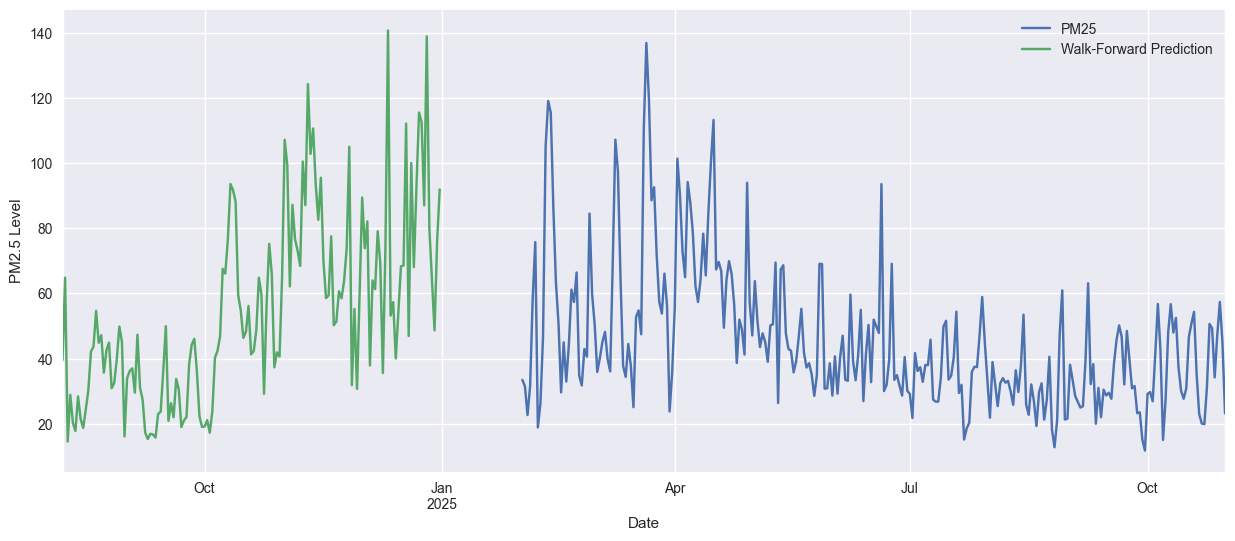

In [106]:
ax = df_pm25_test.plot(label = 'PM2.5 Test Data', figsize=(15, 6))
df_pm25_pred_wfv.plot(ax=ax, label='Walk-Forward Prediction')
plt.ylabel('PM2.5 Level')
plt.xlabel('Date')
plt.legend()
plt.show()

Test MAE: 25.97


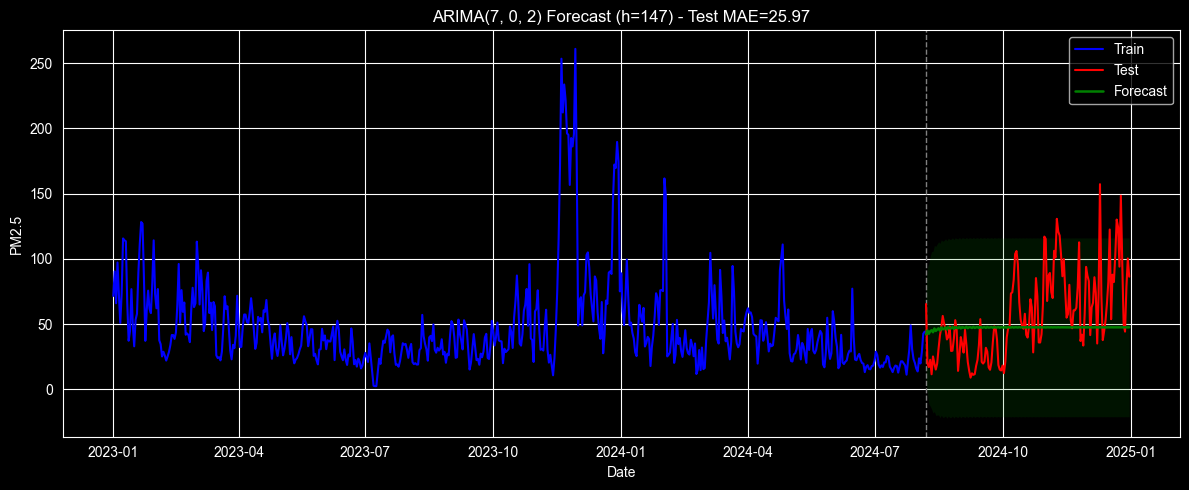

In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.arima.model import ARIMA

# 1) Fit trên TRAIN
best_order = (7, 0, 2)  # hoặc (6,0,1) nếu bạn chọn theo MAE
model = ARIMA(
    df_pm25_train,
    order=best_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit()

# 2) Forecast đa bước bằng độ dài TEST
h = len(df_pm25_test)
fc_res = model.get_forecast(steps=h)
y_fc = pd.Series(fc_res.predicted_mean, index=df_pm25_test.index)  # căn index cho khớp test
ci = fc_res.conf_int(alpha=0.05)  # khoảng tin cậy 95%
ci.index = df_pm25_test.index

# 3) Tính MAE trên TEST (so với baseline nếu muốn)
mae_test = mean_absolute_error(df_pm25_test, y_fc)
print("Test MAE:", round(mae_test, 2))

# 4) Vẽ biểu đồ
plt.figure(figsize=(12,5))

# Train
plt.plot(df_pm25_train.index, df_pm25_train.values, color='blue', label='Train', linewidth=1.5)

# Vạch chia train/test
split_date = df_pm25_test.index[0]
plt.axvline(split_date, color='gray', linestyle='--', linewidth=1)

# Test (ground truth)
plt.plot(df_pm25_test.index, df_pm25_test.values, color='red', label='Test', linewidth=1.5)

# Forecast
plt.plot(y_fc.index, y_fc.values, color='green', label='Forecast', linewidth=1.8)

# (tuỳ chọn) tô khoảng tin cậy
plt.fill_between(
    ci.index,
    ci.iloc[:, 0].values,  # lower
    ci.iloc[:, 1].values,  # upper
    alpha=0.15, color='green', linewidth=0
)

plt.title(f'ARIMA{best_order} Forecast (h={h}) - Test MAE={mae_test:.2f}')
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [92]:
from sklearn.metrics import mean_absolute_error

history = df_pm25_train.copy()  # Khởi tạo history
preds, actuals = [], []

for i in range(len(df_pm25_test) - 3):
    # Train model với history hiện tại
    model = ARIMA(history, order=(7, 0, 2)).fit()

    # Dự báo 3 bước tiếp theo
    forecast = model.forecast(steps=3)

    # Lấy giá trị dự báo cho bước thứ 3 (index 2)
    preds.append(forecast.iloc[2])

    # Lấy giá trị thực tế ở ngày thứ i+3 trong test set
    actuals.append(df_pm25_test.iloc[i + 3])

    # Thêm 1 quan sát thực tế tiếp theo vào history
    # (quan sát đầu tiên của phần test chưa xử lý)
    history = pd.concat([history, df_pm25_test.iloc[[i]]])

mae_3day = mean_absolute_error(actuals, preds)
print("3-day ahead MAE:", round(mae_3day, 2))

3-day ahead MAE: 21.19


In [95]:
from sklearn.metrics import mean_absolute_error

history = df_pm25_train.copy()
preds_day1, preds_day2, preds_day3 = [], [], []
actuals_day1, actuals_day2, actuals_day3 = [], [], []
dates = []

for i in range(len(df_pm25_test) - 3):
    # Fit model
    model = ARIMA(history, order=(7, 0, 2)).fit()

    # Dự báo 3 ngày tiếp theo
    forecast = model.forecast(steps=3)

    # Lưu dự báo cho cả 3 ngày
    preds_day1.append(forecast.iloc[0])
    preds_day2.append(forecast.iloc[1])
    preds_day3.append(forecast.iloc[2])

    # Lưu giá trị thực tế
    actuals_day1.append(df_pm25_test.iloc[i + 1])
    actuals_day2.append(df_pm25_test.iloc[i + 2])
    actuals_day3.append(df_pm25_test.iloc[i + 3])

    # Lưu ngày
    dates.append(df_pm25_test.index[i + 3])

    # Cập nhật history
    history = pd.concat([history, df_pm25_test.iloc[[i]]])

# Tạo DataFrame kết quả
results = pd.DataFrame({
    'Date': dates,
    'Actual_Day3': actuals_day3,
    'Forecast_Day3': preds_day3,
    'Error_Day3': [a - p for a, p in zip(actuals_day3, preds_day3)],
    'Forecast_Day1': preds_day1,
    'Actual_Day1': actuals_day1,
    'Forecast_Day2': preds_day2,
    'Actual_Day2': actuals_day2
})

# Tính MAE cho từng horizon
mae_day1 = mean_absolute_error(actuals_day1, preds_day1)
mae_day2 = mean_absolute_error(actuals_day2, preds_day2)
mae_day3 = mean_absolute_error(actuals_day3, preds_day3)

print(f"MAE Day-1 ahead: {mae_day1:.2f}")
print(f"MAE Day-2 ahead: {mae_day2:.2f}")
print(f"MAE Day-3 ahead: {mae_day3:.2f}")
print(f"\n{'='*80}")
print("Sample results (first 10):")
print(results[['Date', 'Actual_Day3', 'Forecast_Day3', 'Error_Day3']].head(10))
print(f"\n{'='*80}")
print("Full results:")
print(results)

MAE Day-1 ahead: 20.69
MAE Day-2 ahead: 21.31
MAE Day-3 ahead: 21.19

Sample results (first 10):
        Date  Actual_Day3  Forecast_Day3  Error_Day3
0 2024-08-10    22.575417      38.566564  -15.991148
1 2024-08-11    11.451667      54.764268  -43.312601
2 2024-08-12    25.119167      24.548075    0.571092
3 2024-08-13    19.639583      29.419057   -9.779473
4 2024-08-14    15.046667      27.207504  -12.160837
5 2024-08-15    19.607083      24.651088   -5.044005
6 2024-08-16    31.047917      29.942815    1.105102
7 2024-08-17    41.215417      27.504474   13.710943
8 2024-08-18    47.662917      23.707330   23.955586
9 2024-08-19    56.176667      28.063783   28.112884

Full results:
          Date  Actual_Day3  Forecast_Day3  Error_Day3  Forecast_Day1  \
0   2024-08-10    22.575417      38.566564  -15.991148      39.445699   
1   2024-08-11    11.451667      54.764268  -43.312601      64.868194   
2   2024-08-12    25.119167      24.548075    0.571092      14.499126   
3   2024-08-1

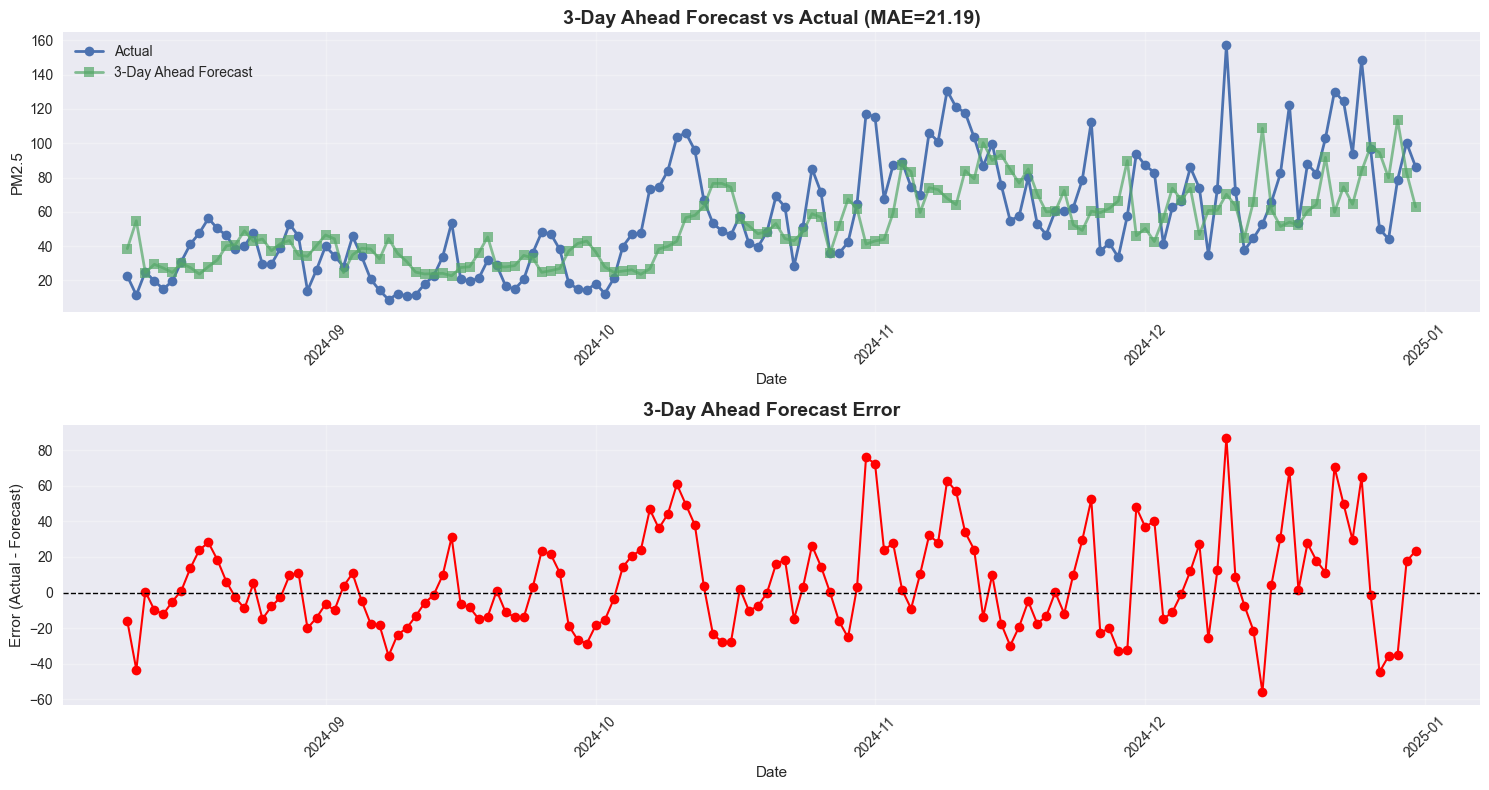


✅ Đã xuất kết quả ra file: 3day_forecast_results.xlsx


In [105]:
import matplotlib.pyplot as plt

# Plot kết quả dự báo 3 ngày
plt.figure(figsize=(15, 8))

# Plot 1: So sánh Actual vs Forecast cho Day-3
plt.subplot(2, 1, 1)
plt.plot(results['Date'], results['Actual_Day3'], 'o-', label='Actual', linewidth=2)
plt.plot(results['Date'], results['Forecast_Day3'], 's-', label='3-Day Ahead Forecast', linewidth=2, alpha=0.7)
plt.title(f'3-Day Ahead Forecast vs Actual (MAE={mae_day3:.2f})', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('PM2.5')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

# Plot 2: Forecast Error
plt.subplot(2, 1, 2)
plt.plot(results['Date'], results['Error_Day3'], 'ro-', linewidth=1.5)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('3-Day Ahead Forecast Error', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Error (Actual - Forecast)')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Xuất ra file Excel (tùy chọn)
results.to_excel('3day_forecast_results.xlsx', index=False)
# print("\n✅ Đã xuất kết quả ra file: 3day_forecast_results.xlsx")


In [97]:


# Đọc file test
df_test = pd.read_csv(r"E:\Document\PROJECT_1\data\hanoi-aqi-weather-data-TEST.csv")

# Chuẩn hóa cột thời gian
df_test['Local Time'] = pd.to_datetime(df_test['Local Time'])
df_test = df_test.set_index('Local Time').sort_index()

# Lấy cột PM2.5, trung bình theo ngày, nội suy giá trị thiếu
df_pm25_test = df_test[['PM25']].resample('D').mean().asfreq('D').interpolate()

df_pm25_test.head()


,PM25
Local Time,
2025-02-01,33.465000
2025-02-02,31.416250
2025-02-03,22.632083
2025-02-04,31.446667
2025-02-05,58.430417


Official Test MAE: 16.93


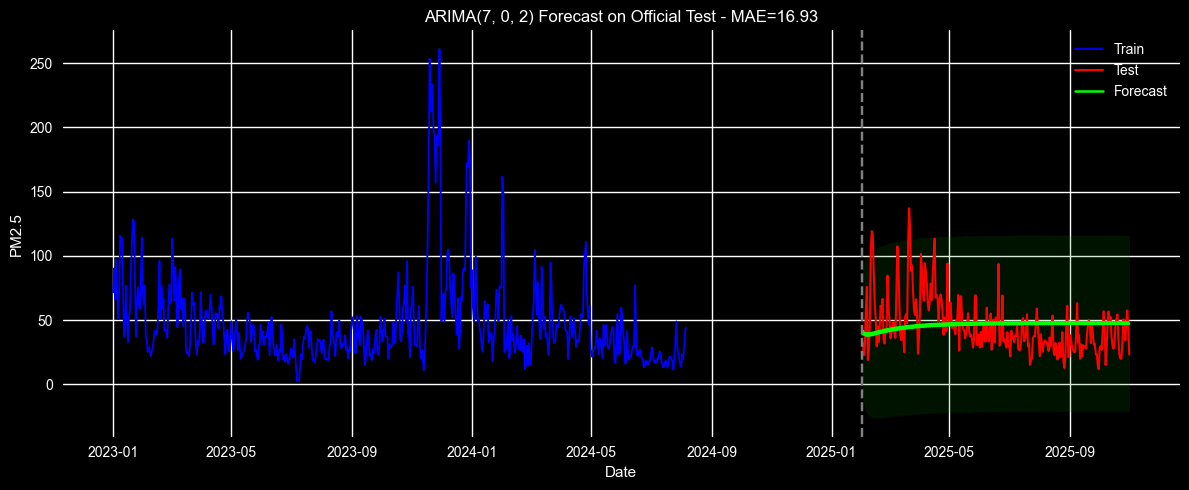

In [104]:
# Mô hình tốt nhất đã chọn
best_order = (7, 0, 2)

# Huấn luyện mô hình trên toàn bộ dữ liệu TRAIN
model = ARIMA(df_pm25_train, order=best_order).fit()

# Dự báo với độ dài bằng test mới
steps = len(df_pm25_test)
forecast_result = model.get_forecast(steps=steps)
y_pred = forecast_result.predicted_mean
y_pred.index = df_pm25_test.index
ci = forecast_result.conf_int(alpha=0.05)
ci.index = df_pm25_test.index

# MAE trên tập test chính thức
mae_test = mean_absolute_error(df_pm25_test, y_pred)  # ✅ Bỏ ['PM25']
print("Official Test MAE:", round(mae_test, 2))

plt.style.use('dark_background')
plt.figure(figsize=(12,5))

# Train
plt.plot(df_pm25_train.index, df_pm25_train, color='blue', label='Train', linewidth=1.3)  # ✅ Bỏ ['PM25']

# Test thật
plt.plot(df_pm25_test.index, df_pm25_test, color='red', label='Test', linewidth=1.5)  # ✅ Bỏ ['PM25']

# Forecast
plt.plot(y_pred.index, y_pred, color='lime', label='Forecast', linewidth=1.8)
plt.fill_between(ci.index, ci.iloc[:,0], ci.iloc[:,1], color='green', alpha=0.15)

# Vạch chia
plt.axvline(df_pm25_test.index[0], color='gray', linestyle='--')

plt.title(f"ARIMA{best_order} Forecast on Official Test - MAE={mae_test:.2f}")
plt.xlabel("Date"); plt.ylabel("PM2.5")
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


In [99]:
model_d0 = ARIMA(df_pm25_train, order=(7, 0, 2)).fit()
model_d1 = ARIMA(df_pm25_train, order=(7, 1, 2)).fit()

forecast_d0 = model_d0.get_forecast(steps=len(df_pm25_test)).predicted_mean
forecast_d1 = model_d1.get_forecast(steps=len(df_pm25_test)).predicted_mean

print("MAE d=0:", mean_absolute_error(df_pm25_test, forecast_d0))
print("MAE d=1:", mean_absolute_error(df_pm25_test, forecast_d1))

MAE d=0: 16.926540444291952
MAE d=1: 19.3482220774978


## Kiểm tra yếu tố mùa vụ

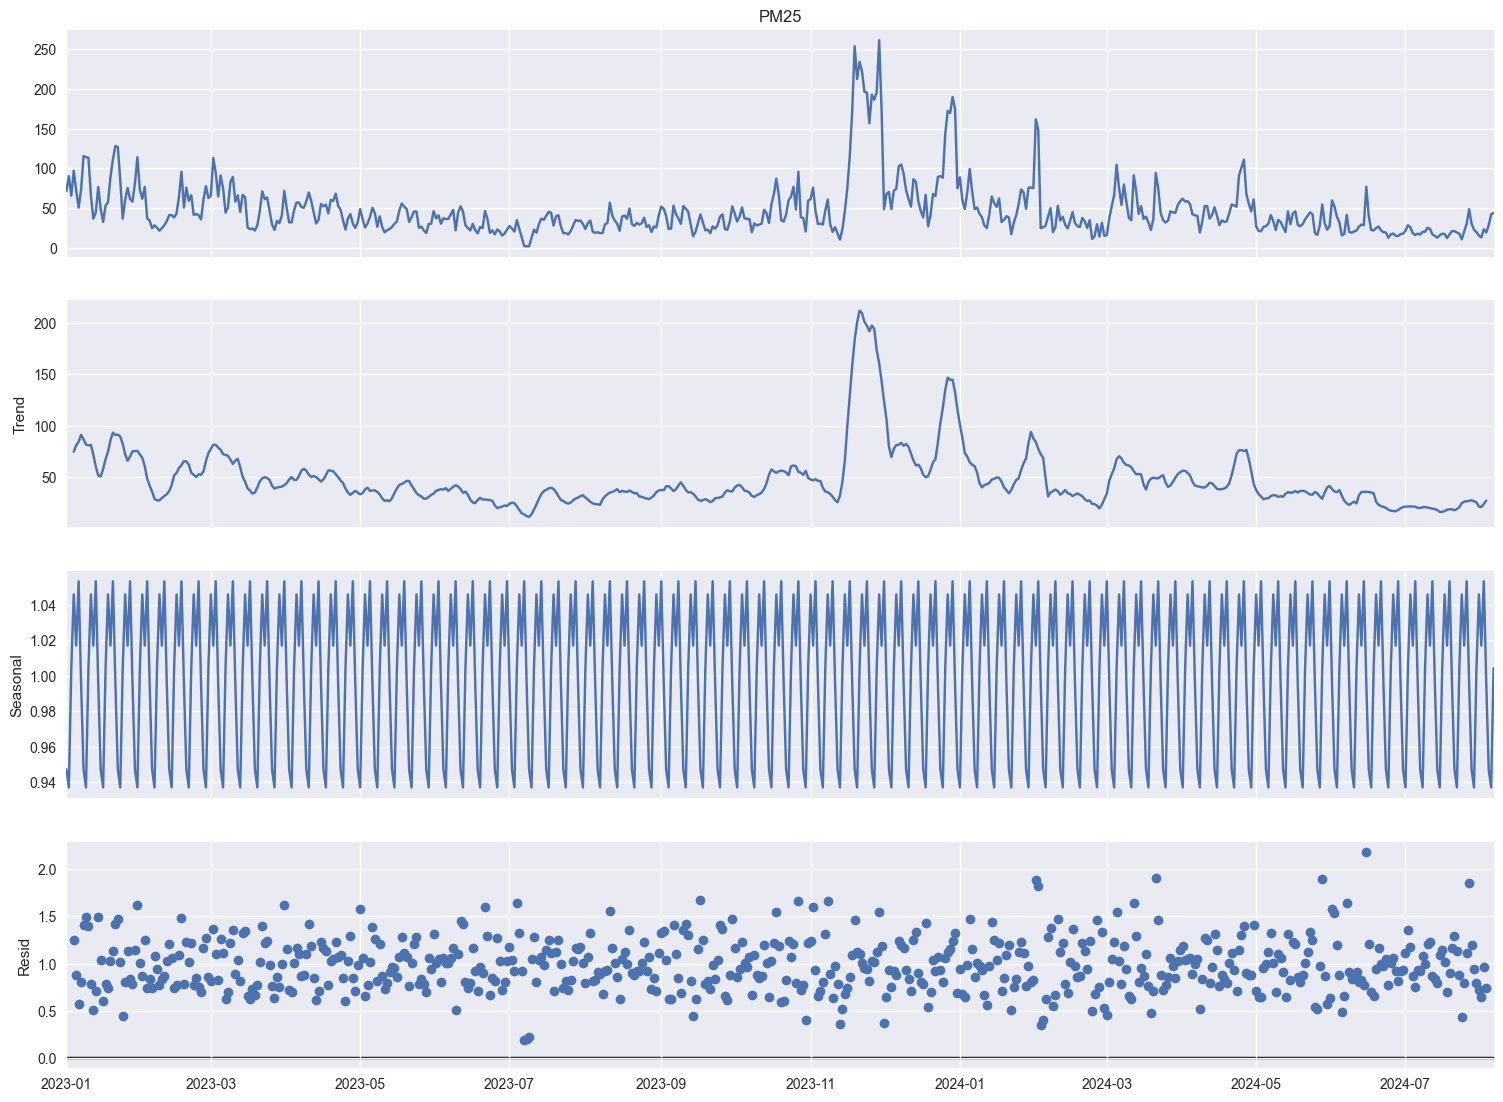

In [102]:
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df_pm25_train, model='multiplicative')
fig = result.plot()
fig.set_size_inches(16,12)

In [107]:
import time
import pandas as pd
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Định nghĩa tham số (bạn cần thêm vào)
p_params = range(0, 3)
q_params = range(0, 3)
P_params = range(0, 2)
Q_params = range(0, 2)
D = 0  # Seasonal differencing
m = 7  # Chu kỳ theo tuần (daily data)

# Danh sách lưu kết quả
results = []

# Tổng số model cần train
total_models = len(p_params) * len(q_params) * len(P_params) * len(Q_params)
current = 0

print(f"Starting SARIMA Grid Search...")
print(f"Total models to train: {total_models}")
print("="*80 + "\n")

for p in p_params:
    for q in q_params:
        for P in P_params:
            for Q in Q_params:
                current += 1
                order = (p, 0, q)
                seasonal_order = (P, D, Q, m)

                try:
                    t0 = time.time()
                    model = SARIMAX(
                        df_pm25_train,
                        order=order,
                        seasonal_order=seasonal_order,
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    ).fit(disp=False)
                    elapsed = round(time.time() - t0, 2)

                    # Dự báo in-sample
                    yhat = model.fittedvalues
                    # Align lengths
                    train_aligned = df_pm25_train.iloc[-len(yhat):]
                    mae = mean_absolute_error(train_aligned, yhat)

                    # Lưu kết quả
                    results.append({
                        'p': p, 'q': q, 'P': P, 'Q': Q,
                        'order': order,
                        'seasonal_order': seasonal_order,
                        'AIC': model.aic,
                        'BIC': model.bic,
                        'MAE': mae,
                        'train_time': elapsed,
                        'converged': True
                    })

                    print(f"[{current}/{total_models}] ✓ SARIMA{order}x{seasonal_order}: "
                          f"AIC={model.aic:.2f}, MAE={mae:.2f}, Time={elapsed}s")

                except Exception as e:
                    results.append({
                        'p': p, 'q': q, 'P': P, 'Q': Q,
                        'order': order,
                        'seasonal_order': seasonal_order,
                        'AIC': None,
                        'BIC': None,
                        'MAE': None,
                        'train_time': None,
                        'converged': False
                    })
                    print(f"[{current}/{total_models}] ✗ SARIMA{order}x{seasonal_order}: {str(e)[:50]}...")

# Tạo DataFrame kết quả
results_df = pd.DataFrame(results)

# Lọc các model thành công
successful_models = results_df[results_df['converged'] == True].copy()

if len(successful_models) > 0:
    # Sắp xếp theo AIC
    successful_models = successful_models.sort_values('AIC')

    print("\n" + "="*80)
    print("GRID SEARCH COMPLETED!")
    print("="*80)
    print(f"Total models attempted: {total_models}")
    print(f"Successfully trained: {len(successful_models)}")
    print(f"Failed: {len(results_df) - len(successful_models)}")

    print("\n" + "="*80)
    print("TOP 10 MODELS BY AIC:")
    print("="*80)
    top10 = successful_models.head(10)[['order', 'seasonal_order', 'AIC', 'BIC', 'MAE', 'train_time']]
    print(top10.to_string(index=False))

    print("\n" + "="*80)
    print("BEST MODEL:")
    print("="*80)
    best = successful_models.iloc[0]
    print(f"Order: {best['order']}")
    print(f"Seasonal Order: {best['seasonal_order']}")
    print(f"AIC: {best['AIC']:.2f}")
    print(f"BIC: {best['BIC']:.2f}")
    print(f"MAE: {best['MAE']:.2f}")
    print(f"Training Time: {best['train_time']}s")
    print("="*80)

    # Lưu kết quả ra file
    results_df.to_csv('sarima_grid_search_results.csv', index=False)
    print("\n✅ Results saved to: sarima_grid_search_results.csv")

else:
    print("\n❌ No models converged successfully!")

Starting SARIMA Grid Search...
Total models to train: 36

[1/36] ✓ SARIMA(0, 0, 0)x(0, 0, 0, 7): AIC=6411.88, MAE=47.51, Time=0.02s
[2/36] ✓ SARIMA(0, 0, 0)x(0, 0, 1, 7): AIC=6013.46, MAE=32.52, Time=0.05s
[3/36] ✓ SARIMA(0, 0, 0)x(1, 0, 0, 7): AIC=5788.02, MAE=23.20, Time=0.03s
[4/36] ✓ SARIMA(0, 0, 0)x(1, 0, 1, 7): AIC=5662.16, MAE=20.71, Time=0.09s
[5/36] ✓ SARIMA(0, 0, 1)x(0, 0, 0, 7): AIC=5817.88, MAE=27.26, Time=0.06s
[6/36] ✓ SARIMA(0, 0, 1)x(0, 0, 1, 7): AIC=5576.41, MAE=23.04, Time=0.1s
[7/36] ✓ SARIMA(0, 0, 1)x(1, 0, 0, 7): AIC=5435.38, MAE=18.55, Time=0.07s
[8/36] ✓ SARIMA(0, 0, 1)x(1, 0, 1, 7): AIC=5264.63, MAE=15.95, Time=0.17s
[9/36] ✓ SARIMA(0, 0, 2)x(0, 0, 0, 7): AIC=5524.33, MAE=20.58, Time=0.06s
[10/36] ✓ SARIMA(0, 0, 2)x(0, 0, 1, 7): AIC=5373.50, MAE=19.48, Time=0.17s
[11/36] ✓ SARIMA(0, 0, 2)x(1, 0, 0, 7): AIC=5328.58, MAE=17.11, Time=0.1s
[12/36] ✓ SARIMA(0, 0, 2)x(1, 0, 1, 7): AIC=5144.80, MAE=14.67, Time=0.23s
[13/36] ✓ SARIMA(1, 0, 0)x(0, 0, 0, 7): AIC=5092.74, 

In [112]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

best_order = (2, 0, 2)
best_seasonal_order = (0, 0, 1, 7)

# Huấn luyện lại mô hình
model_best = SARIMAX(
    df_pm25_train,
    order=best_order,
    seasonal_order=best_seasonal_order,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# In kết quả chi tiết
print(model_best.summary())

                                      SARIMAX Results                                      
Dep. Variable:                                PM25   No. Observations:                  584
Model:             SARIMAX(2, 0, 2)x(0, 0, [1], 7)   Log Likelihood               -2484.870
Date:                             Wed, 05 Nov 2025   AIC                           4981.740
Time:                                     23:45:21   BIC                           5007.856
Sample:                                 01-01-2023   HQIC                          4991.927
                                      - 08-06-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.7148      0.030     56.493      0.000       1.655       1.774
ar.L2         -0.7157      

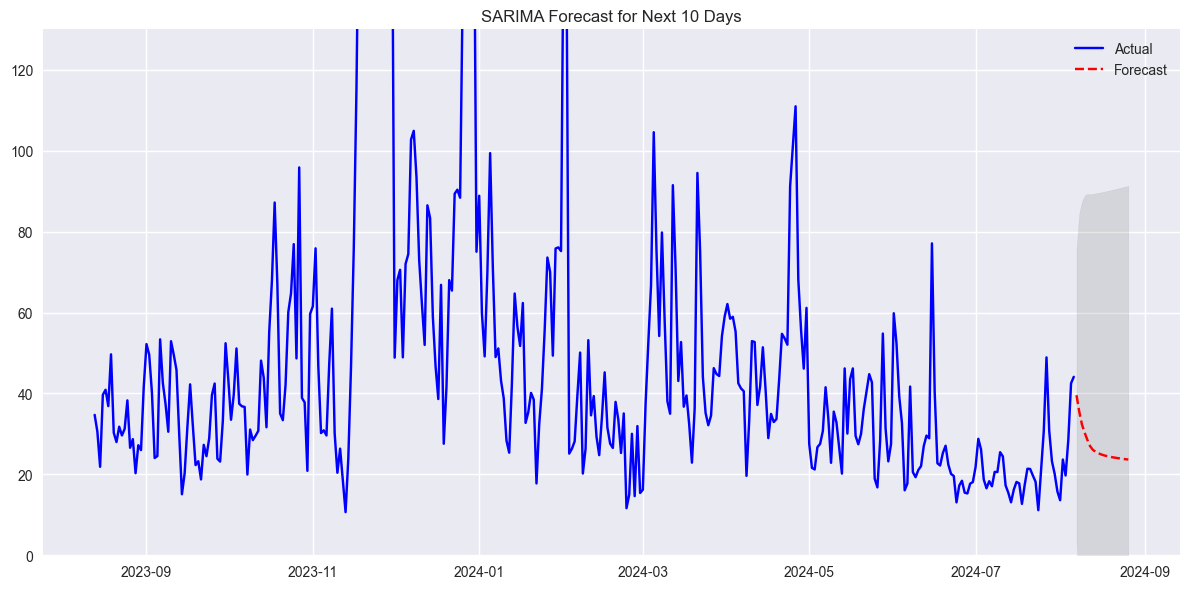

                                      SARIMAX Results                                      
Dep. Variable:                                PM25   No. Observations:                  584
Model:             SARIMAX(2, 0, 2)x(0, 0, [1], 7)   Log Likelihood               -2484.870
Date:                             Wed, 05 Nov 2025   AIC                           4981.740
Time:                                     23:52:41   BIC                           5007.856
Sample:                                 01-01-2023   HQIC                          4991.927
                                      - 08-06-2024                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          1.7148      0.030     56.493      0.000       1.655       1.774
ar.L2         -0.7157      

In [117]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

# 1) Lấy Series train (đảm bảo có tần suất ngày)
y_train = (df_pm25_train['PM25'] if hasattr(df_pm25_train, 'columns') else df_pm25_train).asfreq('D')

# 2) Lấy tham số tốt nhất từ bảng 'best' (kết quả grid search)
best_order = tuple(best['order'])                 # ví dụ (2, 0, 2)
best_seasonal = tuple(best['seasonal_order'])     # ví dụ (0, 0, 1, 7)

# 3) Fit lại mô hình tốt nhất
model_best = SARIMAX(
    y_train,
    order=best_order,
    seasonal_order=best_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

# 4) Dự báo n bước tới (ví dụ 10 ngày)
n_pred_periods = 20
fc_res = model_best.get_forecast(steps=n_pred_periods)
y_fc = fc_res.predicted_mean                      # Series có index thời gian
ci = fc_res.conf_int(alpha=0.05)                  # DataFrame [lower, upper]

# 5) Vẽ
plt.figure(figsize=(12,6))
plt.plot(y_train[-360:], label='Actual', color='blue')   # 360 ngày gần nhất
plt.plot(y_fc.index, y_fc, color='red', linestyle='--', label='Forecast')
plt.fill_between(y_fc.index, ci.iloc[:,0], ci.iloc[:,1], color='grey', alpha=0.2)
plt.ylim((0, 130))
plt.title('SARIMA Forecast for Next 10 Days')
plt.legend()
plt.tight_layout()
plt.show()

# (Tuỳ chọn) In bảng summary
print(model_best.summary())
